# Imputation using Random Sample Imputation, and Missing Indicator

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## For Numerical Data

### Loading and splitting dataset

In [30]:
df = pd.read_csv('E:/Dataset/titanic-Dataset.csv', usecols=['Age', 'Fare', 'Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [31]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
from sklearn.model_selection import train_test_split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

In [35]:
x_train['age_imputed'] = x_train['Age']
x_test['age_imputed'] = x_test['Age']

In [36]:
x_train.tail(3)

,Age,Fare,age_imputed
439,31.0,10.5000,31.0
174,56.0,30.6958,56.0
122,32.5,30.0708,32.5


### Filling Random value in place of NaN

In [44]:
# x_train['age_imputed'][x_train['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
# x_test['age_imputed'][x_test['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

# Instead of using above code, we should use following code bcz Pandas may create new column then update by above code
x_train.loc[x_train['age_imputed'].isnull(), 'age_imputed'] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test.loc[x_test['age_imputed'].isnull(), 'age_imputed'] = x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

##### In production, in case of sampling if fare is 20, model give sample value for age is 22, but in case of again fare is 20 the model may does not give 22 again for the age column, it may changes. Due to this prediction of model may change, that is not good for a model.
##### Therefore, in production use the followig code -

In [57]:
# sample = x_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [46]:
x_train

,Age,Fare,age_imputed
42,NaN,7.8958,17.0
684,60.0,39.0000,60.0
605,36.0,15.5500,36.0
409,NaN,25.4667,28.0
740,NaN,30.0000,26.0
...,...,...,...
360,40.0,27.9000,40.0
709,NaN,15.2458,22.0
439,31.0,10.5000,31.0
174,56.0,30.6958,56.0


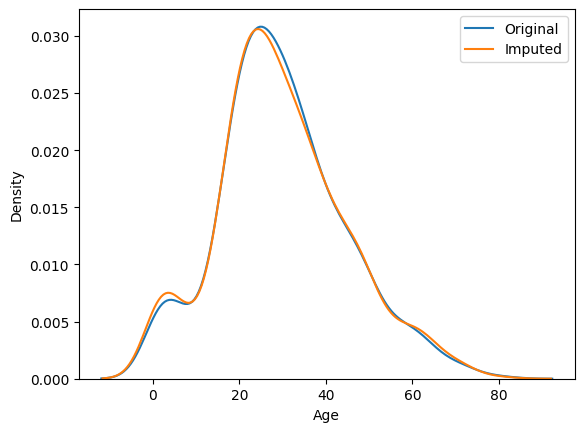

In [51]:
sns.kdeplot(x_train['Age'], label='Original')
sns.kdeplot(x_train['age_imputed'], label='Imputed')
plt.legend()

In [53]:
print('Variance of original column:', x_train['Age'].var())
print('Variance after imputation:', x_train['age_imputed'].var())

Variance of original column: 212.94777780686348
Variance after imputation: 222.3968234003379


In [54]:
x_train.cov()

,Age,Fare,age_imputed
Age,212.947778,53.997398,212.947778
Fare,53.997398,2782.831689,48.468455
age_imputed,212.947778,48.468455,222.396823


<Axes: >

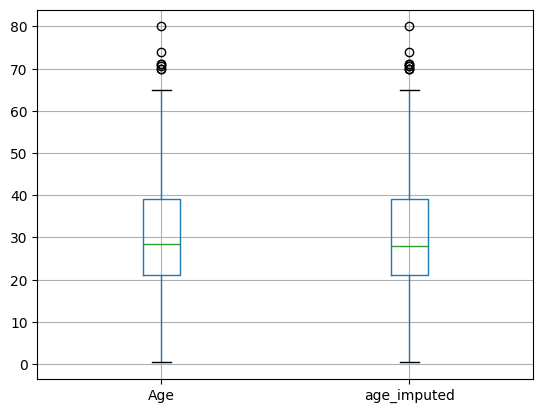

In [55]:
x_train[['Age', 'age_imputed']].boxplot()

## For Categorical Column

In [62]:
data = pd.read_csv('E:/Dataset/advance-house-price-pred.csv', usecols=['FireplaceQu', 'GarageQual', 'SalePrice'])

In [64]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [66]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [67]:
x = data
y = data['SalePrice']

In [70]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [71]:
x_train['firPl_imp'] = x_train['FireplaceQu']
x_test['firPl_imp'] = x_test['FireplaceQu']

x_train['grgQu_imp'] = x_train['GarageQual']
x_test['grgQu_imp'] = x_test['GarageQual']

In [72]:
x_train.sample(2)

,FireplaceQu,GarageQual,SalePrice,firPl_imp,grgQu_imp
98,NaN,Fa,83000,NaN,Fa
1139,Gd,TA,144000,Gd,TA


### Filling value

In [80]:
x_train.loc[x_train['firPl_imp'].isnull(), 'firPl_imp'] = x_train['FireplaceQu'].dropna().sample(x_train['firPl_imp'].isnull().sum()).values
x_test.loc[x_test['firPl_imp'].isnull(), 'firPl_imp'] = x_train['FireplaceQu'].dropna().sample(x_test['firPl_imp'].isnull().sum()).values

x_train.loc[x_train['grgQu_imp'].isnull(), 'grgQu_imp'] = x_train['GarageQual'].dropna().sample(x_train['grgQu_imp'].isnull().sum()).values
x_test.loc[x_test['grgQu_imp'].isnull(), 'grgQu_imp'] = x_train['GarageQual'].dropna().sample(x_test['grgQu_imp'].isnull().sum()).values

In [84]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,firPl_imp,grgQu_imp
1385,NaN,TA,125500,Gd,TA
178,Gd,TA,501837,Gd,TA
118,TA,TA,320000,TA,TA
422,NaN,TA,113000,TA,TA
786,NaN,TA,139000,Po,TA


In [87]:
x['GarageQual'].value_counts()

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

In [93]:
temp = pd.concat(
    [
        x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
        x_train['grgQu_imp'].value_counts() / len(x_train)
    ],
    axis=1)
temp.columns = ['Original', 'Imputed']

In [94]:
temp

,Original,Imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [95]:
temp1 = pd.concat(
    [
        x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
        x_train['firPl_imp'].value_counts() / len(x_train)
    ],
    axis=1)
temp1.columns = ['Original', 'Imputed']

In [97]:
temp1*100

,Original,Imputed
Gd,49.427169,49.229452
TA,41.243863,41.438356
Fa,4.091653,4.109589
Po,2.782324,2.825342
Ex,2.454992,2.397260


In [124]:
x_train['GarageQual'].value_counts()

GarageQual
TA    1049
Fa      41
Gd      11
Po       1
Ex       1
Name: count, dtype: int64

C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_26972\423977276.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x_train[x_train['GarageQual'] == cate]['SalePrice'], ax=ax[0], label=cate)
C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_26972\423977276.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x_train[x_train['GarageQual'] == cate]['SalePrice'], ax=ax[0], label=cate)
C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_26972\423977276.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x_train[x_train['grgQu_imp']==cat]['SalePrice'], ax=ax[1], label=cat)
C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_26972\423977276.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disa

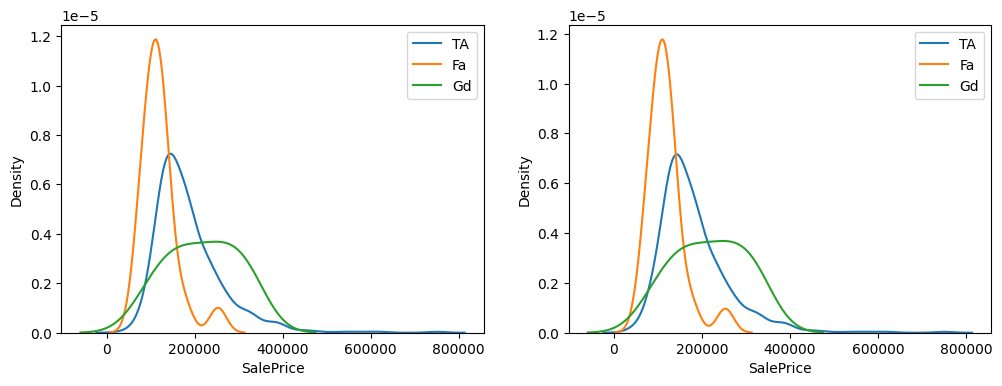

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

for cate in x_train['GarageQual'].dropna().unique():
    sns.kdeplot(x_train[x_train['GarageQual'] == cate]['SalePrice'], ax=ax[0], label=cate)

for cat in x_train['grgQu_imp'].unique():
    sns.kdeplot(x_train[x_train['grgQu_imp']==cat]['SalePrice'], ax=ax[1], label=cat)
    
ax[0].legend()
ax[1].legend()
plt.show()

In [117]:
x_train['grgQu_imp'].unique()

array(['TA', 'Fa', 'Gd', 'Po', 'Ex'], dtype=object)

In [120]:
type(x_train['FireplaceQu'].dropna().unique())

numpy.ndarray

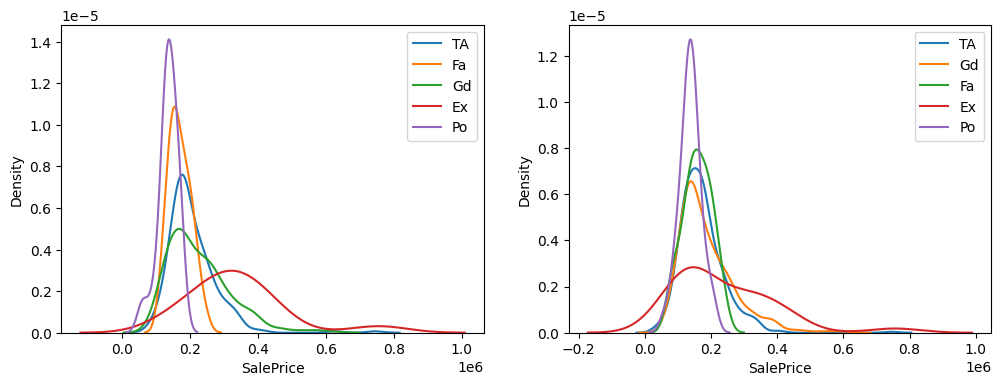

In [122]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

for cate in x_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu']==cate]['SalePrice'], ax=ax[0], label=cate)

for cat in x_train['firPl_imp'].unique():
    sns.kdeplot(x_train[x_train['firPl_imp']==cat]['SalePrice'], ax=ax[1], label=cat)
    
ax[0].legend()
ax[1].legend()
plt.show()